# EDA inicial — Rutas de Última Milla

**Objetivo de esta notebook:** cargar el dataset Amazon Last Mile Routing Research Challenge, aplanarlo a una tabla utilizable, y explorar su calidad antes de definir el modelo de riesgo de incumplimiento de SLA (Fase 1 de Insight).

**Decisión de diseño (ya tomada):** la tabla final tiene **una fila por parada (stop)**, no por ruta. El SLA se cumple o se rompe en cada entrega puntual, no en la ruta completa — si agregáramos a nivel ruta desde el arranque, perderíamos la posibilidad de identificar qué parada puntual fue la que incumplió.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW = "../../data/raw/model_build_inputs"
PROCESSED = "../../data/processed"
FIGURES = "../../outputs/figures"

## 1. Carga de datos

Cargamos solo `route_data.json` y `package_data.json`. **No cargamos `travel_times.json`** a propósito: pesa 1.8 GB de los 2.2 GB totales (el resto del dataset pesa apenas ~400 MB), y es la matriz de tiempos de viaje entre paradas — sirve para optimizar secuencias de ruta (problema de TSP), no para el modelo de riesgo de SLA que estamos construyendo. Cargarlo acá sería usar memoria y tiempo en algo que no responde la pregunta de negocio.

In [2]:
with open(f"{RAW}/route_data.json") as f:
    routes = json.load(f)

with open(f"{RAW}/package_data.json") as f:
    packages = json.load(f)

print(f"Rutas: {len(routes):,}")

Rutas: 6,112


## 2. Aplanar `route_data.json` a nivel parada

Cada ruta trae un diccionario `stops` con una entrada por parada (lat/lng/tipo/zona). Convertimos esto en una fila por `(route_id, stop_id)`, repitiendo los datos de la ruta (estación, fecha, `route_score`, etc.) en cada fila.

**Decisión de limpieza con impacto de negocio:** sacamos las paradas de tipo `Station` (el depósito de salida del camión). No es una entrega a un cliente, así que no tiene sentido de negocio incluirla en un análisis de cumplimiento de SLA — dejarla adentro inflaría el conteo de "paradas" sin aportar información real, y contaminaría cualquier métrica de cumplimiento con una parada que nunca tuvo una promesa de entrega.

In [3]:
stop_rows = []
for route_id, r in routes.items():
    for stop_id, s in r["stops"].items():
        stop_rows.append({
            "route_id": route_id,
            "stop_id": stop_id,
            "station_code": r["station_code"],
            "date": r["date_YYYY_MM_DD"],
            "departure_time_utc": r["departure_time_utc"],
            "executor_capacity_cm3": r["executor_capacity_cm3"],
            "route_score": r["route_score"],
            "lat": s["lat"],
            "lng": s["lng"],
            "stop_type": s["type"],
            "zone_id": s["zone_id"],
        })

stops_df = pd.DataFrame(stop_rows)
print("Con Station incluida:", stops_df.shape)

stops_df = stops_df[stops_df["stop_type"] == "Dropoff"].copy()
print("Solo Dropoff (entregas reales):", stops_df.shape)

Con Station incluida: (904527, 11)
Solo Dropoff (entregas reales): (898415, 11)


## 3. Agregar `package_data.json` a nivel parada

Una parada puede tener **más de un paquete** (34.1% de las paradas, verificado sobre el dataset completo). Como decidimos que la unidad de análisis es la parada, no el paquete, tenemos que **agregar** la info de todos los paquetes de una parada en una sola fila:

- `n_packages`: cantidad de paquetes en la parada.
- `has_time_window`: si **al menos un** paquete de la parada tiene ventana horaria especificada.
- `window_start_utc` / `window_end_utc`: la ventana más amplia entre todos los paquetes de la parada (min de los inicios, max de los finales).
- `total_volume_cm3`: volumen total (suma de depth×height×width de cada paquete).
- `total_planned_service_seconds`: tiempo de servicio total estimado en la parada.
- `any_rejected` / `any_attempted`: si algún paquete de la parada fue rechazado o tuvo un intento de entrega fallido.

**Decisión de limpieza con impacto de negocio (la más importante de esta notebook):** cuando un paquete no tiene ventana horaria (`start_time_utc`/`end_time_utc` en `NaN`), **no lo tratamos como dato faltante para descartar o imputar** — lo tratamos como una categoría real de negocio: "esta entrega no tenía una ventana horaria prometida al cliente". Imputar una ventana horaria inventada sería fabricar una promesa de SLA que nunca existió. Vamos a cuantificar cuántas paradas caen en esta categoría en la sección de gráficos, porque el resultado cambia por completo cómo se puede definir "incumplimiento de SLA" más adelante.

**Nota de tipos:** `window_start_utc`/`window_end_utc` quedan guardados acá como texto (`str`), tal cual vienen del JSON — todavía no son fechas reales para pandas. Se convierten explícitamente a `datetime` recién en la sección 10, cuando se usan por primera vez para calcular. Dejar una columna de fecha sin tipar hasta el momento en que se necesita, en vez de tiparla apenas se crea, es la causa del error de tipos que aparece más abajo — queda documentado ahí.

In [4]:
pkg_rows = []
for route_id, stops in packages.items():
    for stop_id, pkgs in stops.items():
        starts, ends, vols, services = [], [], [], []
        any_rejected = False
        any_attempted = False
        for pkg_id, info in pkgs.items():
            tw = info.get("time_window", {})
            st, en = tw.get("start_time_utc"), tw.get("end_time_utc")
            if isinstance(st, str):
                starts.append(st)
            if isinstance(en, str):
                ends.append(en)
            dims = info.get("dimensions", {})
            d, h, w = dims.get("depth_cm", 0), dims.get("height_cm", 0), dims.get("width_cm", 0)
            vols.append((d or 0) * (h or 0) * (w or 0))
            services.append(info.get("planned_service_time_seconds", 0) or 0)
            if info.get("scan_status") == "REJECTED":
                any_rejected = True
            if info.get("scan_status") == "DELIVERY_ATTEMPTED":
                any_attempted = True
        pkg_rows.append({
            "route_id": route_id,
            "stop_id": stop_id,
            "n_packages": len(pkgs),
            "has_time_window": len(starts) > 0,
            "window_start_utc": min(starts) if starts else None,
            "window_end_utc": max(ends) if ends else None,
            "total_volume_cm3": sum(vols),
            "total_planned_service_seconds": sum(services),
            "any_rejected": any_rejected,
            "any_attempted": any_attempted,
        })

pkg_df = pd.DataFrame(pkg_rows)
print("pkg_df:", pkg_df.shape)

pkg_df: (904527, 10)


## 4. Merge final

In [5]:
final_df = stops_df.merge(pkg_df, on=["route_id", "stop_id"], how="left")
print("Tabla final:", final_df.shape)
final_df.head()

Tabla final: (898415, 19)


,route_id,stop_id,station_code,date,departure_time_utc,executor_capacity_cm3,route_score,lat,lng,stop_type,zone_id,n_packages,has_time_window,window_start_utc,window_end_utc,total_volume_cm3,total_planned_service_seconds,any_rejected,any_attempted
0,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,AD,DLA3,2018-07-27,16:02:10,3313071.0,High,34.099611,-118.283062,Dropoff,P-12.3C,3,True,2018-07-27 16:00:00,2018-07-28 00:00:00,18700.228,177.9,False,False
1,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,AF,DLA3,2018-07-27,16:02:10,3313071.0,High,34.101587,-118.291125,Dropoff,A-1.2D,1,True,2018-07-27 16:00:00,2018-07-28 00:00:00,2466.000,27.0,False,False
2,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,AG,DLA3,2018-07-27,16:02:10,3313071.0,High,34.089727,-118.285530,Dropoff,A-2.1A,2,False,NaN,NaN,19134.644,90.0,False,False
3,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,BA,DLA3,2018-07-27,16:02:10,3313071.0,High,34.096132,-118.292869,Dropoff,A-1.2C,1,False,NaN,NaN,409.920,38.0,False,False
4,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,BE,DLA3,2018-07-27,16:02:10,3313071.0,High,34.098482,-118.286243,Dropoff,P-13.3B,4,False,NaN,NaN,29776.244,167.2,False,False


## 5. Chequeos de calidad: duplicados, nulos, tipos

Antes de confiar en cualquier gráfico o número, verificamos que no haya sorpresas estructurales:

- **Duplicados**: la clave real de una parada es `(route_id, stop_id)`, no `stop_id` solo — la documentación del dataset advierte explícitamente que los IDs de parada se reutilizan entre rutas distintas (`AA`, `AB`, etc. no son únicos globalmente). Si chequeáramos duplicados solo por `stop_id` obtendríamos falsos positivos por todos lados.
- **Nulos**: esperamos nulos en `window_start_utc`/`window_end_utc` (ya sabemos que son ~93%, es una categoría de negocio, no un error) y podemos encontrar algunos en `zone_id`.
- **Tipos**: prestar atención acá a que `window_start_utc`/`window_end_utc` van a aparecer como `object` (texto), no como `datetime64` — es esperado en esta etapa del EDA, pero hay que recordarlo para cuando se usen en cálculos de fecha más adelante (ver nota en sección 3 y la conversión en sección 10).

In [6]:
print("Duplicados por (route_id, stop_id):", final_df.duplicated(subset=["route_id", "stop_id"]).sum())
print()
print("Nulos por columna:")
print(final_df.isna().sum())
print()
print("Tipos de datos:")
print(final_df.dtypes)

Duplicados por (route_id, stop_id): 0

Nulos por columna:
route_id                              0
stop_id                               0
station_code                          0
date                                  0
departure_time_utc                    0
executor_capacity_cm3                 0
route_score                           0
lat                                   0
lng                                   0
stop_type                             0
zone_id                            6515
n_packages                            0
has_time_window                       0
window_start_utc                 839243
window_end_utc                   839243
total_volume_cm3                      0
total_planned_service_seconds         0
any_rejected                          0
any_attempted                         0
dtype: int64

Tipos de datos:
route_id                             str
stop_id                              str
station_code                         str
date                         

## 6. Guardar datos procesados

Guardamos en formato Parquet (no CSV): preserva tipos de datos (booleanos, fechas) sin que se rompan al releerlo, y pesa bastante menos que un CSV equivalente para este volumen de filas.

In [7]:
final_df.to_parquet(f"{PROCESSED}/stops.parquet", index=False)
print("Guardado en data/processed/stops.parquet")

Guardado en data/processed/stops.parquet


## 7. Gráficos exploratorios (3)

### Gráfico 1 — Distribución de `route_score`

`route_score` es el único indicador de calidad disponible para el 100% de las rutas (a diferencia de la ventana horaria, que falta en la mayoría). Importa ver su balance de clases desde ya, porque probablemente termine siendo la base del target de riesgo de SLA en F1-03 — y está muy desbalanceado hacia `Medium`/`High`, con muy pocos casos `Low`.

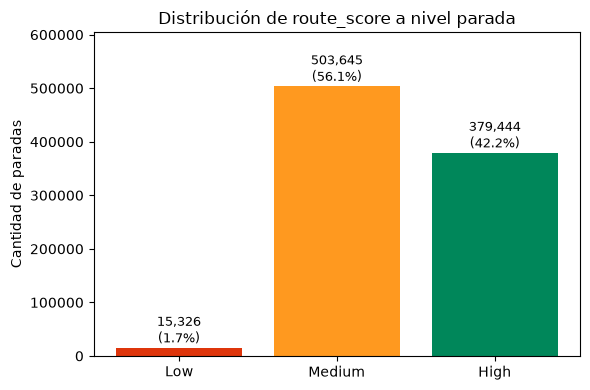

In [8]:
order = ["Low", "Medium", "High"]
colors = ["#de350b", "#ff991f", "#00875a"]
counts = final_df["route_score"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(order, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max()*0.02, f"{v:,}\n({v/len(final_df)*100:.1f}%)", ha="center", fontsize=9)
ax.set_title("Distribución de route_score a nivel parada")
ax.set_ylabel("Cantidad de paradas")
ax.set_ylim(0, counts.max()*1.2)
plt.tight_layout()
plt.savefig(f"{FIGURES}/fig1_route_score.png")
plt.show()

### Gráfico 2 — Paradas con vs. sin ventana horaria

Este es el hallazgo más importante del EDA: la gran mayoría de las paradas **no tienen ninguna ventana horaria prometida al cliente**. Esto no es un problema de datos faltantes que haya que "arreglar" — es información real sobre cómo opera Amazon en este dataset, y redefine qué significa "incumplimiento de SLA" para la Fase 1.

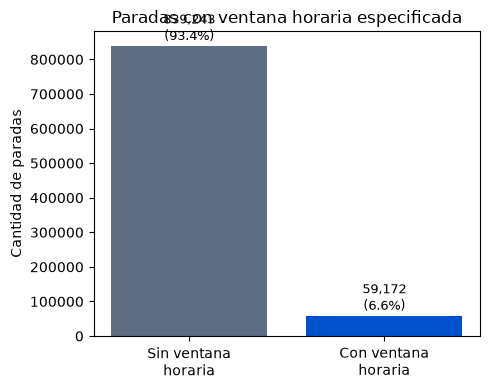

In [9]:
vc = final_df["has_time_window"].value_counts()
labels = ["Sin ventana\nhoraria", "Con ventana\nhoraria"]
values = [vc.get(False, 0), vc.get(True, 0)]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=["#5e6c84", "#0052cc"])
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + max(values)*0.02, f"{v:,}\n({v/len(final_df)*100:.1f}%)", ha="center", fontsize=9)
ax.set_title("Paradas con ventana horaria especificada")
ax.set_ylabel("Cantidad de paradas")
plt.tight_layout()
plt.savefig(f"{FIGURES}/fig2_ventana_horaria.png")
plt.show()

### Gráfico 3 — Paquetes por parada

Confirma que la mayoría de las paradas tienen un solo paquete, pero hay una cola larga de paradas con múltiples paquetes (hasta 113 en un caso). Justifica por qué agregamos package_data por parada en vez de dejarlo a nivel paquete.

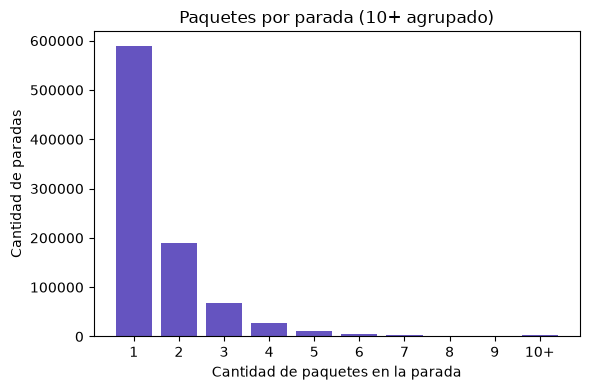

In [10]:
capped = final_df["n_packages"].clip(upper=10)
vc2 = capped.value_counts().reindex(range(1, 11), fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 11), vc2.values, color="#6554c0")
ax.set_xticks(range(1, 11))
ax.set_xticklabels([str(i) for i in range(1, 10)] + ["10+"])
ax.set_title("Paquetes por parada (10+ agrupado)")
ax.set_xlabel("Cantidad de paquetes en la parada")
ax.set_ylabel("Cantidad de paradas")
plt.tight_layout()
plt.savefig(f"{FIGURES}/fig3_paquetes_por_parada.png")
plt.show()

## 8. Conclusión de negocio

**En una línea:** el 93.4% de las paradas de este dataset no tienen una ventana horaria de entrega prometida al cliente, por lo que el riesgo de incumplimiento de SLA de la Fase 1 no se puede definir como "llegó tarde a la ventana horaria" para la mayoría de los casos — se construye en su lugar a partir de `route_score` (el indicador de calidad que Amazon calcula para el 100% de las rutas).

## 9. Definición de la variable objetivo (F1-03)

**Decisión:** el target del modelo de riesgo de SLA es `route_score` (`Low` / `Medium` / `High`), calculado por Amazon a nivel ruta y propagado a cada parada de esa ruta como etiqueta débil (*weak label*). Ya está disponible en `final_df` / `stops.parquet` — no requiere código adicional, se unió en la sección 2.

**Por qué a nivel parada y no a nivel ruta:** con ~898K paradas en vez de ~6K rutas, el modelo cuenta con muchísimo más volumen para aprender patrones reales, y el resultado es accionable a nivel operativo: permite identificar qué paradas puntuales son de riesgo dentro de una ruta, en lugar de solo poder marcar la ruta completa como problemática sin poder decir por qué.

**Limitación conocida, aceptada explícitamente:** al propagar el score de una ruta a cada una de sus paradas, no todas contribuyeron por igual a ese resultado — es una etiqueta con ruido (weak label). Se acepta este trade-off porque el ruido no está correlacionado con las variables predictoras y se diluye con el volumen de datos: la diferencia real entre grupos (por ejemplo, zonas con más incidencia de rutas `Low`) sigue siendo detectable aunque una porción de las etiquetas individuales sea imprecisa.

**Pendiente para la siguiente etapa (feature engineering / modelo baseline):** la clase `Low` representa solo 1.7% de las paradas — un desbalance de clases severo que va a condicionar las métricas de evaluación (accuracy no sirve con este desbalance) y posiblemente requiera balanceo o ponderación de clases.

## 10. Feature engineering — ventana horaria (F1-04)

Dos features nuevas a partir de `window_start_utc` / `window_end_utc`:

- `window_duration_min`: duración de la ventana prometida al cliente, en minutos. Es una resta vectorizada entre las dos columnas de fecha — no hace falta iterar fila por fila, pandas opera sobre las 898K filas de una vez.
- `franja_horaria`: en qué momento del día arranca la ventana (madrugada / mañana / tarde / noche), calculada con `pd.cut` sobre la hora extraída con `.dt.hour`. Los cortes cubren las 24 horas completas (0-6 / 6-12 / 12-19 / 19-24) para no dejar huecos que generen `NaN` silenciosos, y se usa `include_lowest=True` porque `pd.cut` excluye por default el límite inferior del primer bin.

**Corrección de tipos (aparece primero, antes de calcular):** `window_start_utc` y `window_end_utc` llegan a esta celda todavía como texto (`object`), tal cual se guardaron en la sección 3 — nunca se convirtieron a fecha real. Restar dos columnas de texto rompe con `TypeError`, aunque el contenido "parezca" una fecha a simple vista. Por eso se convierten explícitamente con `pd.to_datetime(..., errors="coerce")` antes de cualquier cálculo — `errors="coerce"` convierte a `NaT` cualquier string que no se pueda parsear como fecha, en vez de romper todo el proceso por un solo valor mal formado.

En ambos casos, las paradas sin ventana horaria (`has_time_window == False`) van a dar `NaN` en las features nuevas — es el resultado esperado, no un bug: no se les puede asignar una duración ni una franja horaria a una ventana que no existe.

In [11]:
final_df["window_start_utc"] = pd.to_datetime(final_df["window_start_utc"], errors="coerce")
final_df["window_end_utc"] = pd.to_datetime(final_df["window_end_utc"], errors="coerce")

final_df["window_duration_min"] = (
    final_df["window_end_utc"] - final_df["window_start_utc"]
).dt.total_seconds() / 60

final_df["franja_horaria"] = pd.cut(
    final_df["window_start_utc"].dt.hour,
    bins=[0, 6, 12, 19, 24],
    labels=["madrugada", "mañana", "tarde", "noche"],
    include_lowest=True
)

print("window_duration_min — describe:")
print(final_df["window_duration_min"].describe())
print()
print("franja_horaria — value_counts:")
print(final_df["franja_horaria"].value_counts(dropna=False))

window_duration_min — describe:
count    59172.000000
mean       477.862503
std        162.864483
min        210.000000
25%        420.000000
50%        480.000000
75%        480.000000
max       1439.000000
Name: window_duration_min, dtype: float64

franja_horaria — value_counts:
franja_horaria
NaN          839243
tarde         56680
mañana         1965
madrugada       436
noche            91
Name: count, dtype: int64


## 11. Feature engineering — densidad de paquetes (F1-04)

Tres features nuevas a partir de `n_packages`, `total_volume_cm3` y del identificador de ruta:

- `volumen_promedio_paquete_cm3`: `total_volume_cm3 / n_packages` — distingue una parada con pocos paquetes grandes de una con muchos paquetes chicos, aunque `n_packages` sea igual en ambas.
- `paradas_por_ruta`: cuántas paradas tiene, en total, la ruta a la que pertenece cada fila. Se calcula agrupando por `route_id` y usando `.transform("count")`, que agrupa, cuenta, y devuelve el resultado ya "estirado" de vuelta a las 898K filas originales — cada parada se lleva el número de su propia ruta, sin colapsar la tabla a una fila por ruta (perderíamos el grano de parada que se definió como decisión de diseño en la sección 1).
- `paquetes_por_ruta`: mismo mecanismo que `paradas_por_ruta`, pero sumando (`.transform("sum")`) los paquetes de cada parada en vez de contar filas — el total de paquetes que lleva la ruta entera.

Todas las paradas de una misma ruta van a tener el mismo valor de `paradas_por_ruta` y `paquetes_por_ruta` entre sí — es el comportamiento esperado de `.transform()`, no un error de duplicación.

In [12]:
final_df["volumen_promedio_paquete_cm3"] = final_df["total_volume_cm3"] / final_df["n_packages"]
final_df["paradas_por_ruta"] = final_df.groupby("route_id")["stop_id"].transform("count")
final_df["paquetes_por_ruta"] = final_df.groupby("route_id")["n_packages"].transform("sum")

print("volumen_promedio_paquete_cm3 — describe:")
print(final_df["volumen_promedio_paquete_cm3"].describe())
print()
print("paradas_por_ruta — describe:")
print(final_df["paradas_por_ruta"].describe())
print()
print("paquetes_por_ruta — describe:")
print(final_df["paquetes_por_ruta"].describe())

volumen_promedio_paquete_cm3 — describe:
count    898415.000000
mean      10634.568155
std       12751.579443
min           0.000000
25%        3436.112000
50%        5946.585000
75%       13297.312000
max      300522.600000
Name: volumen_promedio_paquete_cm3, dtype: float64

paradas_por_ruta — describe:
count    898415.000000
mean        153.542885
std          28.408526
min          32.000000
25%         137.000000
50%         156.000000
75%         174.000000
max         237.000000
Name: paradas_por_ruta, dtype: float64

paquetes_por_ruta — describe:
count    898415.000000
mean        242.058473
std          30.105359
min         150.000000
25%         221.000000
50%         243.000000
75%         266.000000
max         304.000000
Name: paquetes_por_ruta, dtype: float64


## 12. Feature engineering — distancia a la siguiente parada (F1-04)

Esta feature necesita un archivo que no habíamos cargado hasta ahora: `actual_sequences.json`. Para cada ruta, trae el **orden real** en que el camión visitó cada parada (un número, no una fecha) — por ejemplo, la parada `AG` puede haber sido la 4ta parada visitada de esa ruta, `BA` la 33ra, etc. Sin este dato no hay forma de saber cuál fue la "parada siguiente" de cada una; el orden en que las filas aparecen en la tabla no tiene ninguna relación con el orden real de visita.

**Pasos, en orden (cada uno depende del anterior):**
1. Cargar `actual_sequences.json` y aplanarlo a `(route_id, stop_id, seq_order)`.
2. Pegarle ese número de secuencia a cada parada de `final_df`.
3. **Ordenar las filas dentro de cada ruta por `seq_order`.** Este paso es el que habilita todo lo demás: sin ordenar primero, "la fila siguiente" no significa nada — sería comparar una parada con otra elegida al azar, no con la que el camión visitó después. Ya lo charlamos como concepto antes de tocar código.
4. Una vez ordenado, tomar la parada siguiente dentro de cada ruta con `.groupby("route_id").shift(-1)` sobre `lat`/`lng` — desplaza los valores una posición hacia arriba dentro de cada grupo, así cada fila queda con el lat/lng de la parada que le sigue.
5. Calcular la distancia real entre ambos puntos con la **fórmula de Haversine**, no con una resta simple de coordenadas: `lat`/`lng` son puntos sobre una esfera, no sobre un plano cuadriculado, así que restar grados directamente da un número que no representa kilómetros reales y que se distorsiona según la latitud. Haversine sí tiene en cuenta la curvatura de la Tierra.

**Resultado esperado:** la última parada de cada ruta (la que no tiene una parada siguiente dentro de la misma ruta) va a dar `NaN` en `distancia_a_siguiente_km` — por eso la cantidad de `NaN` tiene que coincidir exactamente con la cantidad de rutas (6,112). Si no coincide, algo está mal en el orden o en el `groupby`.

In [13]:
with open(f"{RAW}/actual_sequences.json") as f:
    sequences = json.load(f)

seq_rows = []
for route_id, s in sequences.items():
    for stop_id, order in s["actual"].items():
        seq_rows.append({"route_id": route_id, "stop_id": stop_id, "seq_order": order})

seq_df = pd.DataFrame(seq_rows)
print("seq_df:", seq_df.shape)

final_df = final_df.merge(seq_df, on=["route_id", "stop_id"], how="left")
print("Nulos en seq_order tras el merge:", final_df["seq_order"].isna().sum())

seq_df: (904527, 3)
Nulos en seq_order tras el merge: 0


In [14]:
final_df = final_df.sort_values(["route_id", "seq_order"]).reset_index(drop=True)

final_df["next_lat"] = final_df.groupby("route_id")["lat"].shift(-1)
final_df["next_lng"] = final_df.groupby("route_id")["lng"].shift(-1)


def haversine_km(lat1, lng1, lat2, lng2):
    """Distancia entre dos puntos geográficos (en km), considerando la curvatura de la Tierra."""
    R = 6371  # radio de la Tierra en km
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


final_df["distancia_a_siguiente_km"] = haversine_km(
    final_df["lat"], final_df["lng"], final_df["next_lat"], final_df["next_lng"]
)

# limpieza: las columnas auxiliares next_lat/next_lng ya cumplieron su función
final_df = final_df.drop(columns=["next_lat", "next_lng"])

print("distancia_a_siguiente_km — describe:")
print(final_df["distancia_a_siguiente_km"].describe())
print()
n_nan = final_df["distancia_a_siguiente_km"].isna().sum()
n_rutas = final_df["route_id"].nunique()
print(f"NaN: {n_nan} — Rutas: {n_rutas} — ¿Coinciden? {n_nan == n_rutas}")

distancia_a_siguiente_km — describe:
count    892303.000000
mean          0.195197
std           0.240291
min           0.000000
25%           0.083171
50%           0.133753
75%           0.226374
max          13.820808
Name: distancia_a_siguiente_km, dtype: float64

NaN: 6112 — Rutas: 6112 — ¿Coinciden? True
